In [15]:
import csv
import math
import random
import pandas as pd
from pathlib import Path

SEED = 42
N_ROWS = 5000

random.seed(SEED)

# Pola cuaca harian asimetris (naik cepat siang, turun lambat malam)
TEMP_CFG = {
    'peak_mean': 32.0,
    'trough_mean': 24.0,
    'noise_std': 0.8,
    'min_val': 18.0,
    'max_val': 40.0,
    'peak_hour': 13,
    'trough_hour': 4,
}

HUM_CFG = {
    'peak_mean': 80.0,
    'trough_mean': 64.0,
    'noise_std': 1.8,
    'min_val': 30.0,
    'max_val': 98.0,
    'peak_hour': 4,
    'trough_hour': 13,
}

# Suhu tanah: lebih landai & telat dibanding suhu udara
SOIL_TEMP_CFG = {
    'peak_mean': 29.0,
    'trough_mean': 25.0,
    'noise_std': 0.4,
    'min_val': 18.0,
    'max_val': 38.0,
    'peak_hour': 16,
    'trough_hour': 7,
}

# Kelembapan tanah: naik tajam pas disiram (06:00, 12:00, 15:00), lalu turun perlahan
# (evaporasi) sampai siraman berikutnya. Boost & decay disetel biar seimbang dalam
# siklus 24 jam (3 x boost ~= total decay harian), jadi nggak mentok terus di batas atas.
SOIL_CFG = {
    'initial': 55.0,
    'pump_boost': 12.0,
    'decay_day': 2.0,
    'decay_night': 1.0,
    'noise_std': 0.6,
    'min': 15.0,
    'max': 95.0,
}

# NPK & EC: proses AR(1) biar smooth & nyambung antar baris (bukan random lepas tiap baris)
N_CFG  = {'mean': 65.0,  'ar_coef': 0.97, 'noise_std': 2.0,  'min_val': 5.0,  'max_val': 200.0}
P_CFG  = {'mean': 90.0,  'ar_coef': 0.97, 'noise_std': 2.2,  'min_val': 5.0,  'max_val': 200.0}
K_CFG  = {'mean': 110.0, 'ar_coef': 0.97, 'noise_std': 2.5,  'min_val': 5.0,  'max_val': 200.0}
EC_CFG = {'mean': 2.4,   'ar_coef': 0.95, 'noise_std': 0.10, 'min_val': 0.2, 'max_val': 5.0}

print(f"Seed: {SEED}, Rows: {N_ROWS}")


Seed: 42, Rows: 5000


# Helper & Definisi Fase

In [16]:
def gauss_clamp(mean, std, lo, hi):
    return max(lo, min(hi, random.gauss(mean, std)))

def asimetris_daily(hour, peak_mean, trough_mean, noise_std, peak_hour, trough_hour, min_val, max_val, **kwargs):
    """
    Pola suhu/kelembapan harian asimetris (per baris, berdasarkan jam).
    Naik cepat dari trough ke peak, turun lambat kembali ke trough.
    Diadaptasi dari asimetris_daily() versi time-series di generate_dataset_1.ipynb.
    """
    if peak_hour >= trough_hour:
        delta_rise = peak_hour - trough_hour
    else:
        delta_rise = (peak_hour + 24) - trough_hour
    delta_fall = 24.0 - delta_rise

    amplitude = (peak_mean - trough_mean) / 2.0
    base = (peak_mean + trough_mean) / 2.0

    hour_shifted = (hour - trough_hour) % 24.0

    if hour_shifted < delta_rise:
        value = base - amplitude * math.cos(math.pi * hour_shifted / delta_rise)
    else:
        t_fall = hour_shifted - delta_rise
        value = base + amplitude * math.cos(math.pi * t_fall / delta_fall)

    value += random.gauss(0, noise_std)
    return max(min_val, min(max_val, value))

def generate_ar1(n, mean, ar_coef, noise_std, min_val, max_val, **kwargs):
    """Proses AR(1) smooth buat NPK & EC (tiap baris nyambung ke baris sebelumnya)."""
    series = [0.0] * n
    series[0] = max(min_val, min(max_val, random.gauss(mean, noise_std)))
    for t in range(1, n):
        val = ar_coef * series[t - 1] + (1.0 - ar_coef) * mean + random.gauss(0, noise_std)
        series[t] = max(min_val, min(max_val, val))
    return series

def simulate_soil(n, jam_arr, cfg, watering_hours=(6, 12, 15)):
    """Kelembapan tanah: turun perlahan (evaporasi siang/malam beda), naik pas jam siram."""
    soil = [0.0] * n
    soil[0] = cfg['initial']
    for t in range(1, n):
        jam_t = jam_arr[t]
        is_siang = 6 <= jam_t < 18
        decay = cfg['decay_day'] if is_siang else cfg['decay_night']
        value = soil[t - 1] - decay
        if jam_t in watering_hours:
            value += cfg['pump_boost']
        value += random.gauss(0, cfg['noise_std'])
        soil[t] = max(cfg['min'], min(cfg['max'], value))
    return soil

def get_fase(plant_age):
    """4 fase pertumbuhan Paprika, sesuai Haifa Crop Guide - Pepper:
    https://www.haifa-group.com/articles/crop-guide-nutrients-pepper"""
    if plant_age <= 30:
        return "establishment"    # <=30 hari setelah tanam, rasio N:P:K = 1:2:1 (P tinggi buat akar)
    elif plant_age <= 55:
        return "vegetatif"        # rasio N:P:K = 1:1:1, kuantitas naik seiring pertumbuhan
    elif plant_age <= 75:
        return "berbunga"         # dari mulai berbunga s/d fruit-set, rasio N:P:K = 2:1:3
    else:
        return "pematangan"       # fruit development & maturation, rasio N:P:K = 2:1:3

# Threshold minimum NPK per fase (mg/kg), rasio dibuat persis sesuai Haifa Crop Guide
FASE_THRESHOLDS = {
    "establishment": {"n": 40, "p": 80,  "k": 40},   # 1:2:1
    "vegetatif":     {"n": 60, "p": 60,  "k": 60},   # 1:1:1
    "berbunga":      {"n": 70, "p": 35,  "k": 105},  # 2:1:3
    "pematangan":    {"n": 74, "p": 37,  "k": 111},  # 2:1:3 (kuantitas sedikit naik dari fase berbunga)
}

LABEL_NAMES = {
    0: "Tidak perlu",
    1: "Urea/ZA",
    2: "SP-36",
    3: "KCl",
    4: "Urea/ZA + SP-36",
    5: "Urea/ZA + KCl",
    6: "SP-36 + KCl",
    7: "Urea/ZA + SP-36 + KCl",
    8: "NPK 15-15-15",
    9: "NPK rendah N",
}

print("Helper ready.")
print("Fase:", list(FASE_THRESHOLDS.keys()))
print("Label:", LABEL_NAMES)


Helper ready.
Fase: ['establishment', 'vegetatif', 'berbunga', 'pematangan']
Label: {0: 'Tidak perlu', 1: 'Urea/ZA', 2: 'SP-36', 3: 'KCl', 4: 'Urea/ZA + SP-36', 5: 'Urea/ZA + KCl', 6: 'SP-36 + KCl', 7: 'Urea/ZA + SP-36 + KCl', 8: 'NPK 15-15-15', 9: 'NPK rendah N'}


# Generate Data Mentah

In [17]:
n = N_ROWS
jam_arr  = [i % 24 for i in range(n)]   # jam berurutan (0-23, berputar), bukan acak
hari_arr = [i // 24 for i in range(n)]  # umur tanaman (hari) sejak awal tanam, mulai dari 0

# Cuaca & suhu tanah: smooth, mengikuti kurva harian berdasarkan jam
suhu_udara       = [asimetris_daily(j, **TEMP_CFG) for j in jam_arr]
kelembapan_udara = [asimetris_daily(j, **HUM_CFG) for j in jam_arr]
suhu_tanah       = [asimetris_daily(j, **SOIL_TEMP_CFG) for j in jam_arr]

# Kelembapan tanah: smooth, dipengaruhi evaporasi & jadwal pompa
kelembapan_tanah = simulate_soil(n, jam_arr, SOIL_CFG)

# NPK & EC: smooth, proses AR(1) nyambung antar baris
nitrogen = generate_ar1(n, **N_CFG)
fosfor   = generate_ar1(n, **P_CFG)
kalium   = generate_ar1(n, **K_CFG)
ec       = generate_ar1(n, **EC_CFG)

raw_data = []
for i in range(n):
    row = {
        "jam":              jam_arr[i],
        "soil_moisture":    round(kelembapan_tanah[i], 1),
        "soil_temperature": round(suhu_tanah[i], 1),
        "air_temperature":  round(suhu_udara[i], 1),
        "air_humidity":     round(kelembapan_udara[i], 1),
        "nitrogen":         round(nitrogen[i], 1),
        "fosfor":           round(fosfor[i], 1),
        "kalium":           round(kalium[i], 1),
        "ec":               round(ec[i], 2),
        "plant_age":        hari_arr[i],
    }
    raw_data.append(row)

df_mentah = pd.DataFrame(raw_data)
print(f"Data mentah: {len(df_mentah)} baris, {hari_arr[-1] + 1} hari sejak tanam")
df_mentah.head(10)


Data mentah: 5000 baris, 209 hari sejak tanam


,jam,soil_moisture,soil_temperature,air_temperature,air_humidity,nitrogen,fosfor,kalium,ec,plant_age
0,0,55.0,27.6,25.2,78.9,62.7,86.9,104.9,2.50,0
1,1,52.2,26.1,24.6,80.2,64.5,91.1,102.7,2.33,0
2,2,50.5,25.8,24.3,76.8,62.9,92.3,107.9,2.25,0
3,3,49.6,25.0,24.6,79.5,62.1,92.0,110.8,2.24,0
4,4,49.4,26.5,23.9,78.9,63.5,88.0,114.1,2.23,0
5,5,48.0,25.4,23.0,79.6,62.8,86.6,113.4,2.20,0
6,6,58.8,25.6,25.2,75.9,63.2,88.2,112.1,2.18,0
7,7,57.5,24.8,25.8,74.2,63.1,86.6,114.2,2.29,0
8,8,55.0,25.0,27.1,73.5,62.7,86.7,108.2,2.37,0
9,9,53.6,25.4,28.8,70.6,64.0,86.3,111.9,2.47,0


# Distribusi data mentah

In [18]:
df_mentah.describe().round(2)

,jam,soil_moisture,soil_temperature,air_temperature,air_humidity,nitrogen,fosfor,kalium,ec,plant_age
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,11.49,69.41,27.00,27.99,71.98,67.29,89.07,108.91,2.39,103.67
std,6.93,10.71,1.47,2.95,5.90,7.94,8.47,10.10,0.31,60.15
min,0.00,29.20,23.90,21.90,58.30,40.60,62.40,77.20,1.40,0.00
25%,5.00,62.10,25.70,25.30,66.60,62.40,83.50,102.10,2.17,52.00
50%,11.00,69.70,27.00,28.00,72.10,67.50,89.10,109.20,2.40,104.00
75%,17.00,77.30,28.40,30.70,77.30,72.62,95.00,116.43,2.60,156.00
max,23.00,95.00,30.10,34.90,84.50,93.70,115.70,135.10,3.34,208.00


# Labelling dataset buat irigasi

In [19]:
def label_irigasi(row):
    """Siram murni berdasarkan jadwal tetap: jam 06:00, 12:00, 15:00."""
    return 1 if row["jam"] in (6, 12, 15) else 0

print("Fungsi label_irigasi() ready.")


Fungsi label_irigasi() ready.


# Labelling dataset pupuk

In [20]:
def label_pupuk(row):
    """Rekomendasi pupuk berdasarkan defisiensi NPK per fase (Haifa Crop Guide)."""
    fase = get_fase(row["plant_age"])
    thresholds = FASE_THRESHOLDS[fase]

    n_val = row["nitrogen"]
    p_val = row["fosfor"]
    k_val = row["kalium"]
    ec    = row["ec"]

    # Cek defisiensi berdasarkan threshold fase
    n_low = n_val < thresholds["n"]
    p_low = p_val < thresholds["p"]
    k_low = k_val < thresholds["k"]

    # EC sangat rendah -> perketat threshold 20%
    if ec < 1.0:
        n_low = n_low or (n_val < thresholds["n"] * 1.2)
        p_low = p_low or (p_val < thresholds["p"] * 1.2)
        k_low = k_low or (k_val < thresholds["k"] * 1.2)

    # EC sangat tinggi -> oversaturated, skip pupuk
    if ec > 4.0:
        return 0

    # Map defisiensi ke rekomendasi
    if   n_low and p_low and k_low: rec = 7
    elif n_low and p_low:           rec = 4
    elif n_low and k_low:           rec = 5
    elif p_low and k_low:           rec = 6
    elif n_low:                     rec = 1
    elif p_low:                     rec = 2
    elif k_low:                     rec = 3
    else:
        # Cek borderline (semua pas-pasan)
        margin_n = n_val - thresholds["n"]
        margin_p = p_val - thresholds["p"]
        margin_k = k_val - thresholds["k"]
        if margin_n < 15 and margin_p < 15 and margin_k < 15:
            rec = 8   # NPK 15-15-15 (maintenance)
        else:
            rec = 0   # Tidak perlu

    # 5% noise
    if random.random() < 0.05:
        rec = random.choice(list(LABEL_NAMES.keys()))

    return rec

print("Fungsi label_pupuk() ready.")


Fungsi label_pupuk() ready.


# Labelling dan Split dataset jadi 2 (irigasi dan pupuk)

In [21]:
sensor_cols = ["jam", "soil_moisture", "soil_temperature", "air_temperature",
               "air_humidity", "nitrogen", "fosfor", "kalium", "ec"]

rows_irigasi = []
rows_pupuk = []

for row in raw_data:
    # Dataset irigasi: jam + 8 sensor + label
    row_ir = {col: row[col] for col in sensor_cols}
    row_ir["irrigation_action"] = label_irigasi(row)
    rows_irigasi.append(row_ir)

    # Dataset pupuk: jam + 8 sensor + plant_age + fase + label
    row_pk = {col: row[col] for col in sensor_cols}
    row_pk["plant_age"] = row["plant_age"]
    row_pk["fase"] = get_fase(row["plant_age"])
    row_pk["recommendation"] = label_pupuk(row)
    rows_pupuk.append(row_pk)

df_irigasi = pd.DataFrame(rows_irigasi)
df_pupuk = pd.DataFrame(rows_pupuk)

print(f"Dataset irigasi: {len(df_irigasi)} baris, {df_irigasi.columns.tolist()}")
print(f"Dataset pupuk:   {len(df_pupuk)} baris, {df_pupuk.columns.tolist()}")


Dataset irigasi: 5000 baris, ['jam', 'soil_moisture', 'soil_temperature', 'air_temperature', 'air_humidity', 'nitrogen', 'fosfor', 'kalium', 'ec', 'irrigation_action']
Dataset pupuk:   5000 baris, ['jam', 'soil_moisture', 'soil_temperature', 'air_temperature', 'air_humidity', 'nitrogen', 'fosfor', 'kalium', 'ec', 'plant_age', 'fase', 'recommendation']


# Cek distribus label irigasi

In [22]:
dist_ir = df_irigasi["irrigation_action"].value_counts().sort_index()
for val, count in dist_ir.items():
    label = "Tidak siram" if val == 0 else "Siram"
    print(f"  {val} ({label}): {count} ({count/len(df_irigasi)*100:.1f}%)")


  0 (Tidak siram): 4375 (87.5%)
  1 (Siram): 625 (12.5%)


# Cek Distribusi Label Pupuk

In [23]:
dist_pk = df_pupuk["recommendation"].value_counts().sort_index()
for val, count in dist_pk.items():
    print(f"  {val} = {LABEL_NAMES.get(val, '?'):30s} {count:5d} ({count/len(df_pupuk)*100:.1f}%)")


  0 = Tidak perlu                     1401 (28.0%)
  1 = Urea/ZA                         1235 (24.7%)
  2 = SP-36                            208 (4.2%)
  3 = KCl                              506 (10.1%)
  4 = Urea/ZA + SP-36                   22 (0.4%)
  5 = Urea/ZA + KCl                   1519 (30.4%)
  6 = SP-36 + KCl                       32 (0.6%)
  7 = Urea/ZA + SP-36 + KCl             22 (0.4%)
  8 = NPK 15-15-15                      25 (0.5%)
  9 = NPK rendah N                      30 (0.6%)


# Cek distribusi per dfase

In [24]:
print("--- Per Fase ---")
print(df_pupuk["fase"].value_counts().to_string())
print()
print("--- Rekomendasi per Fase ---")
print(pd.crosstab(df_pupuk["fase"], df_pupuk["recommendation"]))


--- Per Fase ---
fase
pematangan       3176
establishment     744
vegetatif         600
berbunga          480

--- Rekomendasi per Fase ---
recommendation    0     1    2    3   4     5   6   7   8   9
fase                                                         
berbunga        100   129    1  142   2    98   1   2   2   3
establishment   522     2  191    8   5     2   3   2   6   3
pematangan      271  1040   12  350  14  1416  25  17  10  21
vegetatif       508    64    4    6   1     3   3   1   7   3


# Visualisasi Data

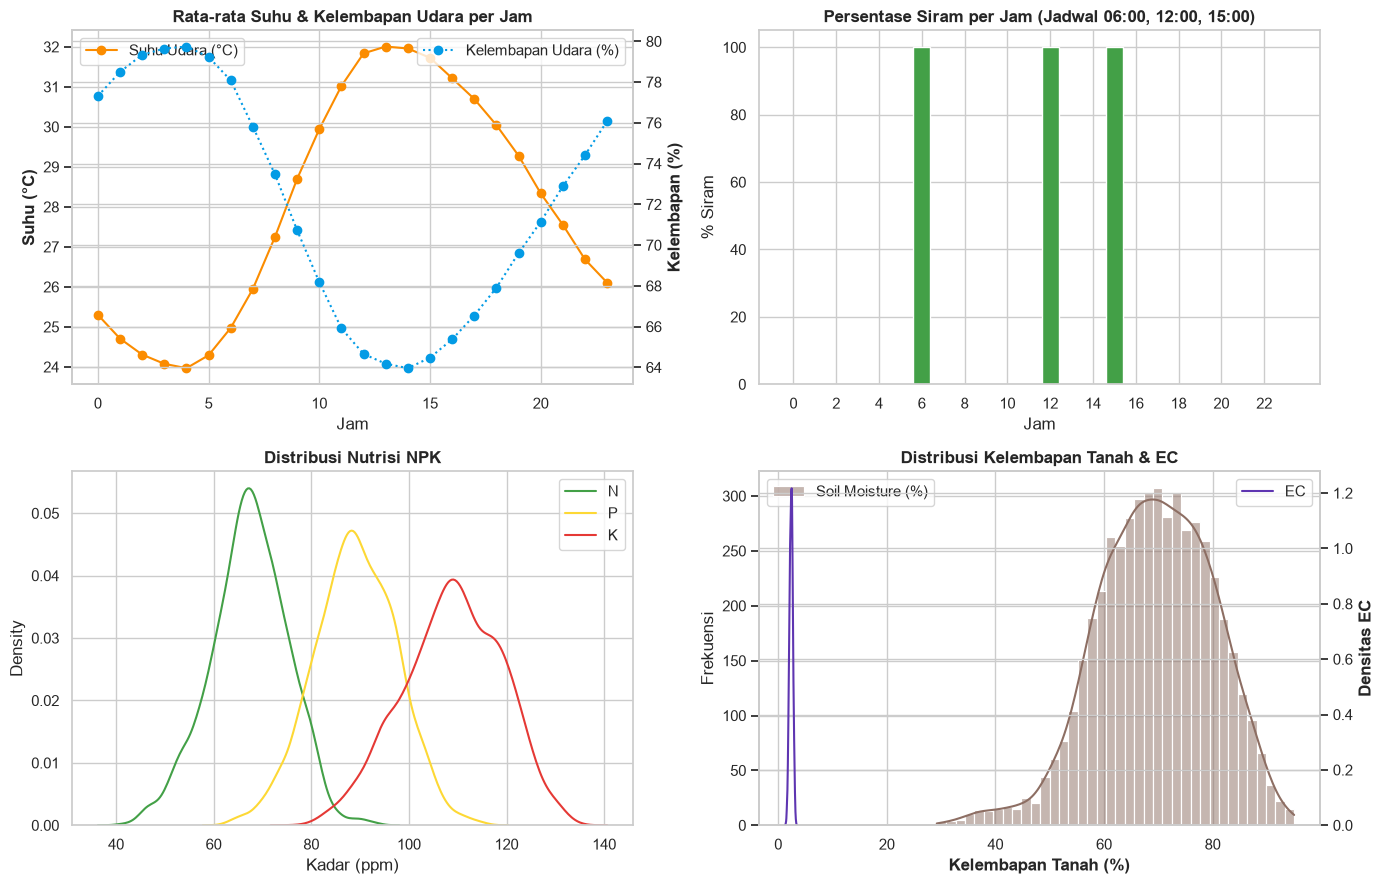

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Pola suhu & kelembapan udara per jam (cek kurva asimetris harian)
agg = df_mentah.groupby("jam")[["air_temperature", "air_humidity"]].mean()

ax1 = axes[0, 0]
ax1.plot(agg.index, agg["air_temperature"], color="#FB8C00", marker="o", label="Suhu Udara (°C)")
ax1.set_xlabel("Jam")
ax1.set_ylabel("Suhu (°C)", fontweight="bold")
ax1.set_title("Rata-rata Suhu & Kelembapan Udara per Jam", fontweight="bold")
ax1.legend(loc="upper left")

ax1r = ax1.twinx()
ax1r.plot(agg.index, agg["air_humidity"], color="#039BE5", ls=":", marker="o", label="Kelembapan Udara (%)")
ax1r.set_ylabel("Kelembapan (%)", fontweight="bold")
ax1r.legend(loc="upper right")

# 2. Persentase siram per jam (cek jadwal 06:00, 12:00, 15:00)
ax2 = axes[0, 1]
irr_per_jam = df_irigasi.groupby("jam")["irrigation_action"].mean() * 100
ax2.bar(irr_per_jam.index, irr_per_jam.values, color="#43A047")
ax2.set_title("Persentase Siram per Jam (Jadwal 06:00, 12:00, 15:00)", fontweight="bold")
ax2.set_xlabel("Jam")
ax2.set_ylabel("% Siram")
ax2.set_xticks(range(0, 24, 2))

# 3. Distribusi nutrisi NPK
ax3 = axes[1, 0]
sns.kdeplot(df_mentah["nitrogen"], ax=ax3, label="N", color="#43A047")
sns.kdeplot(df_mentah["fosfor"], ax=ax3, label="P", color="#FDD835")
sns.kdeplot(df_mentah["kalium"], ax=ax3, label="K", color="#E53935")
ax3.set_title("Distribusi Nutrisi NPK", fontweight="bold")
ax3.set_xlabel("Kadar (ppm)")
ax3.legend()

# 4. Distribusi kelembapan tanah & EC
ax4 = axes[1, 1]
sns.histplot(df_mentah["soil_moisture"], ax=ax4, color="#8D6E63", kde=True, label="Soil Moisture (%)")
ax4.set_xlabel("Kelembapan Tanah (%)", fontweight="bold")
ax4.set_ylabel("Frekuensi")
ax4.set_title("Distribusi Kelembapan Tanah & EC", fontweight="bold")

ax4r = ax4.twinx()
sns.kdeplot(df_mentah["ec"], ax=ax4r, color="#5E35B1", label="EC")
ax4r.set_ylabel("Densitas EC", fontweight="bold")
ax4.legend(loc="upper left")
ax4r.legend(loc="upper right")

plt.tight_layout()
plt.show()


# Cek Smoothness (3 hari pertama, per baris)

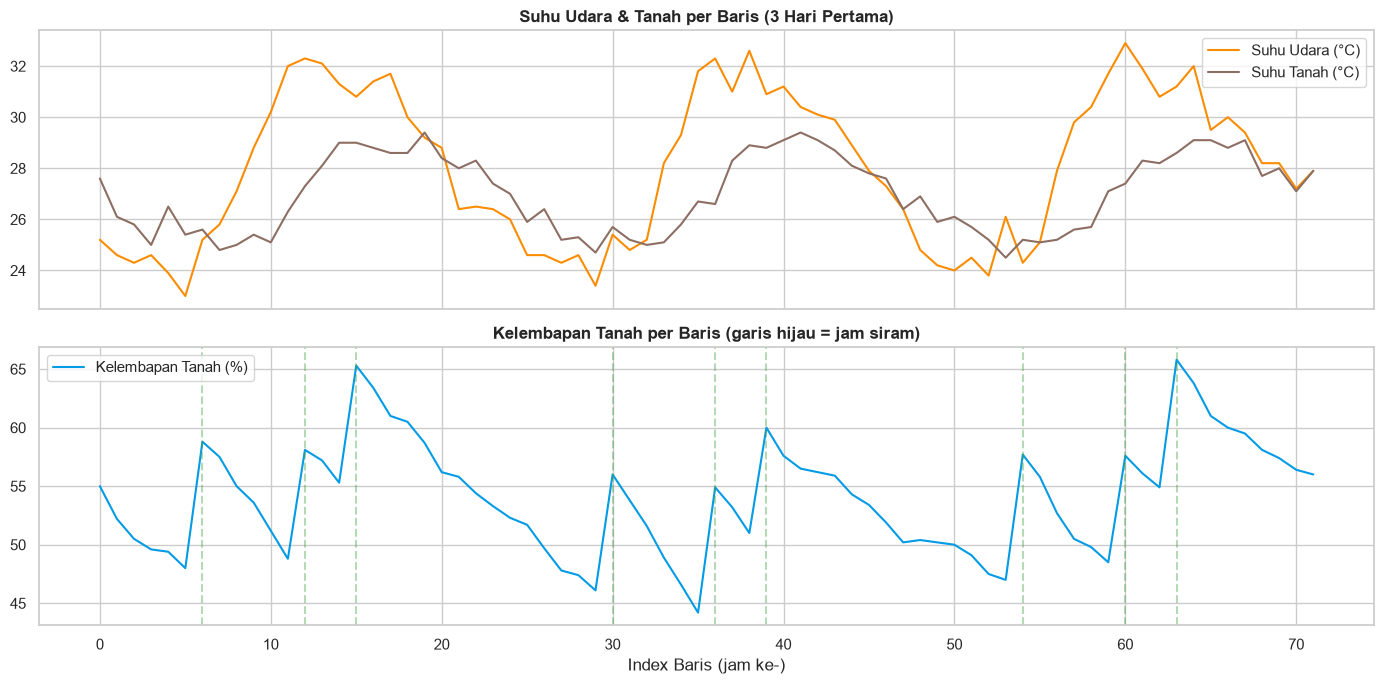

In [26]:
import matplotlib.pyplot as plt

sampel = df_mentah.iloc[:72]  # 3 hari pertama (24 jam x 3)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(sampel.index, sampel["air_temperature"], color="#FB8C00", label="Suhu Udara (°C)")
axes[0].plot(sampel.index, sampel["soil_temperature"], color="#8D6E63", label="Suhu Tanah (°C)")
axes[0].set_title("Suhu Udara & Tanah per Baris (3 Hari Pertama)", fontweight="bold")
axes[0].legend()

axes[1].plot(sampel.index, sampel["soil_moisture"], color="#039BE5", label="Kelembapan Tanah (%)")
for jam_siram in [6, 12, 15]:
    for hari in range(3):
        axes[1].axvline(hari * 24 + jam_siram, color="#43A047", ls="--", alpha=0.4)
axes[1].set_title("Kelembapan Tanah per Baris (garis hijau = jam siram)", fontweight="bold")
axes[1].set_xlabel("Index Baris (jam ke-)")
axes[1].legend()

plt.tight_layout()
plt.show()


# Preview Dataset

In [27]:
print("=== Dataset Irigasi (5 baris pertama) ===")
display(df_irigasi.head())

print("\n=== Dataset Pupuk (5 baris pertama) ===")
display(df_pupuk.head())


=== Dataset Irigasi (5 baris pertama) ===


,jam,soil_moisture,soil_temperature,air_temperature,air_humidity,nitrogen,fosfor,kalium,ec,irrigation_action
0,0,55.0,27.6,25.2,78.9,62.7,86.9,104.9,2.50,0
1,1,52.2,26.1,24.6,80.2,64.5,91.1,102.7,2.33,0
2,2,50.5,25.8,24.3,76.8,62.9,92.3,107.9,2.25,0
3,3,49.6,25.0,24.6,79.5,62.1,92.0,110.8,2.24,0
4,4,49.4,26.5,23.9,78.9,63.5,88.0,114.1,2.23,0



=== Dataset Pupuk (5 baris pertama) ===


,jam,soil_moisture,soil_temperature,air_temperature,air_humidity,nitrogen,fosfor,kalium,ec,plant_age,fase,recommendation
0,0,55.0,27.6,25.2,78.9,62.7,86.9,104.9,2.50,0,establishment,0
1,1,52.2,26.1,24.6,80.2,64.5,91.1,102.7,2.33,0,establishment,0
2,2,50.5,25.8,24.3,76.8,62.9,92.3,107.9,2.25,0,establishment,0
3,3,49.6,25.0,24.6,79.5,62.1,92.0,110.8,2.24,0,establishment,0
4,4,49.4,26.5,23.9,78.9,63.5,88.0,114.1,2.23,0,establishment,0


# Simpan ke CSV

In [28]:
Path("data").mkdir(exist_ok=True)

df_mentah.to_csv("data/dataset_mentah.csv", index=False)
df_irigasi.to_csv("data/dataset_irigasi.csv", index=False)
df_pupuk.to_csv("data/dataset_pupuk.csv", index=False)

print("Tersimpan:")
print("  data/dataset_mentah.csv    <- data sensor mentah (tanpa label)")
print("  data/dataset_irigasi.csv   <- jam + 8 sensor + irrigation_action")
print("  data/dataset_pupuk.csv     <- jam + 8 sensor + plant_age + fase + recommendation")

Tersimpan:
  data/dataset_mentah.csv    <- data sensor mentah (tanpa label)
  data/dataset_irigasi.csv   <- jam + 8 sensor + irrigation_action
  data/dataset_pupuk.csv     <- jam + 8 sensor + plant_age + fase + recommendation
